# Nonlinear Probing — Existence vs Form

**Companion to** [research/02-nonlinear-probing.md](../research/02-nonlinear-probing.md)

A *nonlinear probe* replaces the linear classifier with an **MLP** $\hat{y}=g_\theta(z)$ on the same
**frozen** latents. It answers a weaker but vital question — *does the information exist at all*,
linearly encoded or not? — so its accuracy is an **upper bound** on what a linear probe can reach.
The price: a probe powerful enough to *compute* the answer blurs the line between reading the latent
and solving the task from scratch.

**What we will see:**
1. An MLP probe bends the decision boundary and recovers what a linear probe cannot (the upper bound).
2. The linear–nonlinear accuracy **gap** is a diagnostic for *how* an attribute is encoded.
3. As probe capacity grows, accuracy rises — but so does control-task accuracy, so **selectivity** drops.
4. Minimum Description Length (MDL) grades representations by *bits*, not accuracy (Voita & Titov).
5. A nonlinear probe yields **no single steering direction** — a real limitation for manipulation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## Experiment 1: The MLP probe bends the boundary (the upper bound)

**Question:** When a feature is encoded *nonlinearly*, what does an MLP probe recover that a linear
probe cannot?

We build a 2D latent whose binary attribute follows an **XOR** pattern: class 1 lives in the
top-right and bottom-left quadrants. No straight line separates it, so a linear probe is stuck at
chance, while an MLP probe carves a curved region. Because a linear map is a special case of an MLP,
we always have $\mathrm{Acc}_{\text{MLP}} \ge \mathrm{Acc}_{\text{linear}}$.

In [2]:
np.random.seed(1)
n = 800
Z = np.random.randn(n, 2) * 1.1
# XOR-encoded attribute: label = (z1>0) XOR (z2>0)
y = ((Z[:, 0] > 0) ^ (Z[:, 1] > 0)).astype(int)
Ztr, Zte, ytr, yte = train_test_split(Z, y, test_size=0.3, random_state=1)

lin = LogisticRegression().fit(Ztr, ytr)
mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=1).fit(Ztr, ytr)
acc_lin, acc_mlp = lin.score(Zte, yte), mlp.score(Zte, yte)
print(f'Linear probe accuracy : {acc_lin:.3f}')
print(f'MLP probe accuracy    : {acc_mlp:.3f}')

Linear probe accuracy : 0.496
MLP probe accuracy    : 0.996


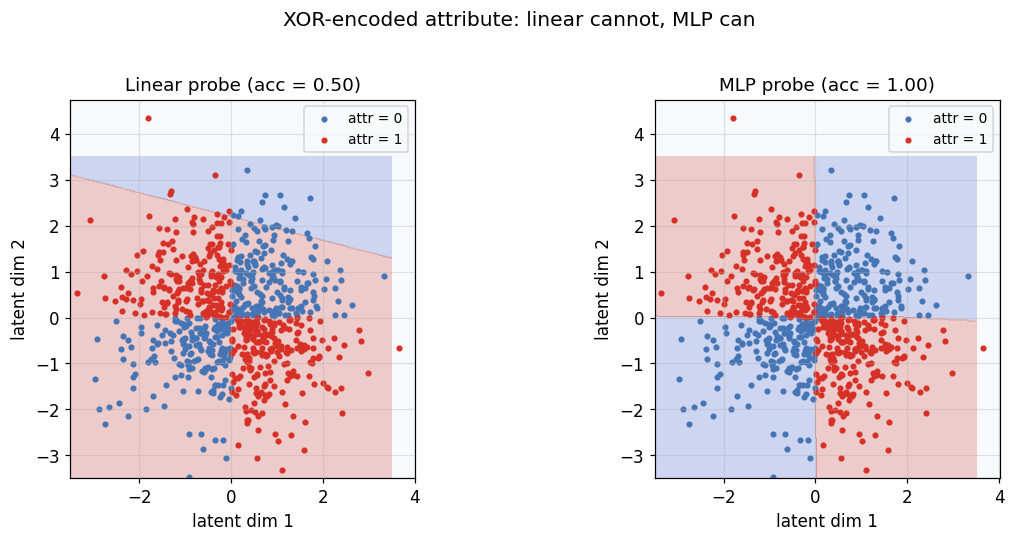

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, 300), np.linspace(-3.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
for ax, model, name, acc in [(axes[0], lin, 'Linear probe', acc_lin),
                             (axes[1], mlp, 'MLP probe', acc_mlp)]:
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(Z[y == 0, 0], Z[y == 0, 1], s=9, c='#4575b4', label='attr = 0')
    ax.scatter(Z[y == 1, 0], Z[y == 1, 1], s=9, c='#d73027', label='attr = 1')
    ax.set_title(f'{name} (acc = {acc:.2f})')
    ax.set_xlabel('latent dim 1'); ax.set_ylabel('latent dim 2')
    ax.set_aspect('equal'); ax.legend(loc='upper right', fontsize=9)
fig.suptitle('XOR-encoded attribute: linear cannot, MLP can', y=1.02)
plt.tight_layout(); plt.show()

### What you see

The left panel shows the linear probe choosing one flat cut — hopeless against an XOR layout, so it
sits at ~0.50. The right panel shows the MLP stitching together the two diagonal quadrants and
reaching ~0.95+.

The information was *present the whole time*; only the probe's expressive power changed. This is the
defining property of nonlinear probing: its accuracy is an **upper bound** — it reveals whether the
attribute exists in the latent *at all*, regardless of geometry. A low linear score followed by a
high MLP score is the signature of a **nonlinearly encoded** feature.

## Experiment 2: The linear–nonlinear gap as a diagnostic

**Question:** Can the *pair* (linear acc, MLP acc) tell us how — or whether — an attribute is encoded?

We construct three latents for the same kind of label and read off the diagnostic table from the
note: **linear** encoding (both high), **nonlinear/XOR** encoding (linear low, MLP high), and **no
information** (both at chance). The two bars per scenario are the whole diagnosis.

In [4]:
def eval_pair(Z, y, seed=0):
    Ztr, Zte, ytr, yte = train_test_split(Z, y, test_size=0.3, random_state=seed)
    a_lin = LogisticRegression(max_iter=1000).fit(Ztr, ytr).score(Zte, yte)
    a_mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000,
                          random_state=seed).fit(Ztr, ytr).score(Zte, yte)
    return a_lin, a_mlp

np.random.seed(2)
m = 800
# (a) linear encoding
Za = np.random.randn(m, 6)
ya = (Za @ np.array([1.5, -1.0, 0.8, 0, 0, 0]) > 0).astype(int)
# (b) nonlinear (XOR) encoding
Zb = np.random.randn(m, 6)
yb = ((Zb[:, 0] > 0) ^ (Zb[:, 1] > 0)).astype(int)
# (c) no information (random labels independent of Z)
Zc = np.random.randn(m, 6)
yc = np.random.randint(0, 2, m)

results = {
    'linear\nencoding': eval_pair(Za, ya, 2),
    'nonlinear\nencoding': eval_pair(Zb, yb, 2),
    'no\ninformation': eval_pair(Zc, yc, 2),
}
for k, (l, mlp_a) in results.items():
    print(f'{k.replace(chr(10), " "):24s}  linear={l:.2f}  MLP={mlp_a:.2f}')

linear encoding           linear=0.98  MLP=0.98
nonlinear encoding        linear=0.47  MLP=0.94
no information            linear=0.43  MLP=0.52


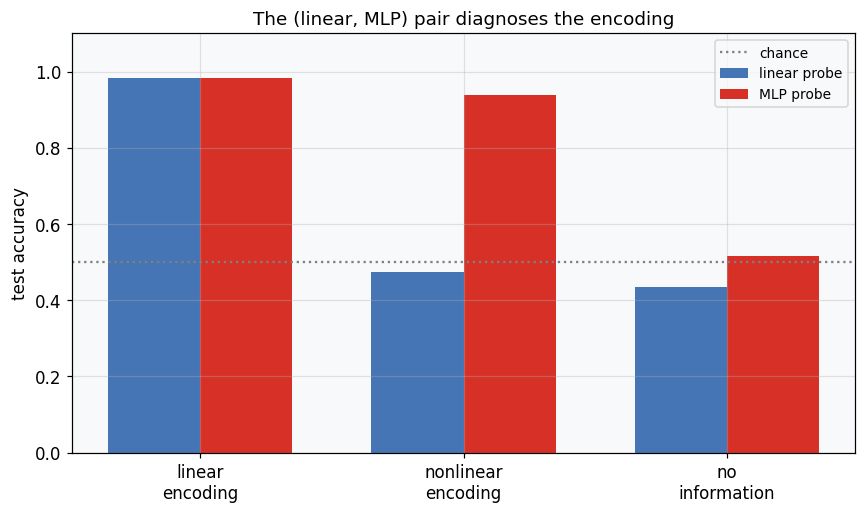

In [5]:
labels = list(results)
lin_v = [results[k][0] for k in labels]
mlp_v = [results[k][1] for k in labels]
x = np.arange(len(labels)); width = 0.35
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(x - width / 2, lin_v, width, label='linear probe', color='#4575b4')
ax.bar(x + width / 2, mlp_v, width, label='MLP probe', color='#d73027')
ax.axhline(0.5, color='gray', ls=':', label='chance')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('test accuracy'); ax.set_ylim(0, 1.1)
ax.set_title('The (linear, MLP) pair diagnoses the encoding')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Three distinct signatures:
- **Linear encoding** — both bars high: information present *and* linearly accessible (ideal for
  arithmetic and steering).
- **Nonlinear encoding** — linear low, MLP high: information present but *folded* nonlinearly; you
  cannot steer it with a fixed direction.
- **No information** — both at chance: the latent simply does not carry the attribute (try another
  layer or adapter).

Reading either probe alone is misleading: linear-only would wrongly declare scenarios (b) and (c)
both "absent"; MLP-only could not separate *form* from *existence*. The **gap** between them is the
informative quantity — exactly the decision rule the Latent-Anything API exposes.

## Experiment 3: Capacity rises accuracy — and erodes selectivity

**Question:** If a bigger probe always scores higher, why not always use the biggest?

Hewitt & Liang (2019) answer with **control tasks**: assign each input *type* a fixed random label
that can only be learned by *memorizing*. **Selectivity = real-task acc − control-task acc**. We
sweep probe capacity from linear (hidden size 0) up to a wide MLP and watch real accuracy, control
accuracy, and selectivity move.

In [6]:
np.random.seed(3)
n_types, dim, per_type = 60, 8, 30
protos = np.random.randn(n_types, dim) * 1.5
direction = np.random.randn(dim)
real_label = (protos @ direction > 0).astype(int)   # linearly decodable
ctrl_label = np.random.randint(0, 2, n_types)        # random per type

Xb, t = [], []
for ti in range(n_types):
    Xb.append(protos[ti] + 0.30 * np.random.randn(per_type, dim)); t += [ti] * per_type
Xb = np.vstack(Xb); t = np.array(t)
y_real, y_ctrl = real_label[t], ctrl_label[t]
idx = np.random.permutation(len(t)); cut = int(0.7 * len(t)); tr, te = idx[:cut], idx[cut:]

def acc_for(hidden, y):
    if hidden == 0:
        m = LogisticRegression(max_iter=1000)
    else:
        m = MLPClassifier(hidden_layer_sizes=(hidden, hidden), max_iter=3000, random_state=3)
    m.fit(Xb[tr], y[tr]); return m.score(Xb[te], y[te])

caps = [0, 8, 32, 128, 256]
real_acc = [acc_for(h, y_real) for h in caps]
ctrl_acc = [acc_for(h, y_ctrl) for h in caps]
selectivity = [r - c for r, c in zip(real_acc, ctrl_acc)]
for h, r, c, s in zip(caps, real_acc, ctrl_acc, selectivity):
    tag = 'linear' if h == 0 else f'MLP {h}'
    print(f'{tag:9s}  real={r:.2f}  control={c:.2f}  selectivity={s:+.2f}')

linear     real=0.97  control=0.65  selectivity=+0.32
MLP 8      real=1.00  control=0.99  selectivity=+0.01
MLP 32     real=1.00  control=1.00  selectivity=-0.00
MLP 128    real=1.00  control=1.00  selectivity=-0.00
MLP 256    real=1.00  control=1.00  selectivity=-0.00


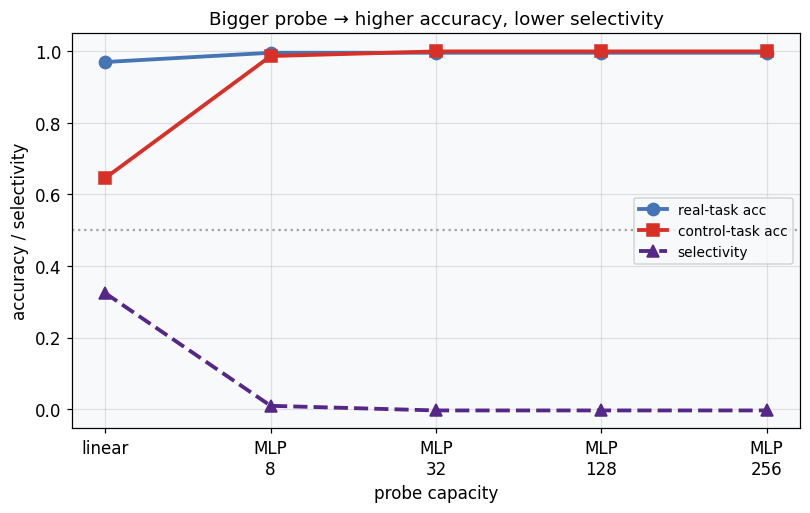

In [7]:
xs = range(len(caps))
labels = ['linear'] + [f'MLP\n{h}' for h in caps[1:]]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(xs, real_acc, 'o-', lw=2.5, ms=8, color='#4575b4', label='real-task acc')
ax.plot(xs, ctrl_acc, 's-', lw=2.5, ms=8, color='#d73027', label='control-task acc')
ax.plot(xs, selectivity, '^--', lw=2.5, ms=8, color='#542788', label='selectivity')
ax.axhline(0.5, color='gray', ls=':', alpha=0.7)
ax.set_xticks(list(xs)); ax.set_xticklabels(labels)
ax.set_xlabel('probe capacity'); ax.set_ylabel('accuracy / selectivity')
ax.set_title('Bigger probe → higher accuracy, lower selectivity')
ax.legend(loc='center right', fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Real-task accuracy (blue) is high everywhere — even the linear probe handles this linearly-decodable
label. But as capacity grows, **control-task accuracy (red) climbs**: the wide MLP memorizes the 60
random type→label assignments and generalizes them to held-out occurrences. Consequently
**selectivity (purple) falls**.

This is the central caution of nonlinear probing: a high MLP accuracy can come from the probe's own
muscle rather than the latent's content. So a bare nonlinear-probe accuracy is *uninterpretable* —
always pair it with selectivity (or the MDL measure in the next experiment). It is also why
Latent-Anything keeps the linear probe as the trustworthy default.

## Experiment 4: Minimum Description Length grades representations in bits

**Question:** Is there a measure that rewards *easily* decodable information, not just decodable?

Voita & Titov (2020) recast probing as **transmission**: how many bits to send the labels $Y$ given
the representation $Z$? We use **online (prequential) coding** — train the probe on a growing prefix
of the data, and for each new block pay $-\log_2 p_\theta(y\mid z)$ bits. A representation that lets
the probe learn *fast* compresses the labels into far fewer bits. We compare a **strong**, a
**weak**, and a **random** representation of the same labels.

In [8]:
np.random.seed(4)
N, dim = 1500, 8
y4 = np.random.randint(0, 2, N)
s = (2 * y4 - 1).astype(float)
w = np.random.randn(dim); w /= np.linalg.norm(w)
# strong: clear signal; weak: faint signal; random: no signal
Z_strong = np.outer(s, w) * 2.2 + np.random.randn(N, dim)
Z_weak   = np.outer(s, w) * 0.6 + np.random.randn(N, dim)
Z_random = np.random.randn(N, dim)

def online_codelength(Z, y, n_blocks=10, seed=4):
    rng = np.random.RandomState(seed); order = rng.permutation(len(y))
    Z, y = Z[order], y[order]
    bounds = np.linspace(0, len(y), n_blocks + 1).astype(int)
    cum_bits, bits_curve, seen = 0.0, [], []
    for i in range(n_blocks):
        a, b = bounds[i], bounds[i + 1]
        if i == 0:
            block_bits = (b - a) * np.log2(2)            # uniform code for first block
        else:
            m = MLPClassifier(hidden_layer_sizes=(64,), max_iter=2000,
                              random_state=seed).fit(Z[:a], y[:a])
            p = np.clip(m.predict_proba(Z[a:b]), 1e-6, 1)
            block_bits = -np.log2(p[np.arange(b - a), y[a:b]]).sum()
        cum_bits += block_bits
        bits_curve.append(cum_bits); seen.append(b)
    return np.array(seen), np.array(bits_curve), cum_bits

reps = {'strong': Z_strong, 'weak': Z_weak, 'random': Z_random}
curves, totals = {}, {}
for name, Z in reps.items():
    seen, curve, total = online_codelength(Z, y4)
    curves[name] = (seen, curve); totals[name] = total
uniform_bits = N * np.log2(2)
for name in reps:
    print(f'{name:7s}  MDL = {totals[name]:7.0f} bits   '
          f'compression = {uniform_bits / totals[name]:.2f}x')

strong   MDL =     234 bits   compression = 6.42x
weak     MDL =    1970 bits   compression = 0.76x
random   MDL =    2432 bits   compression = 0.62x


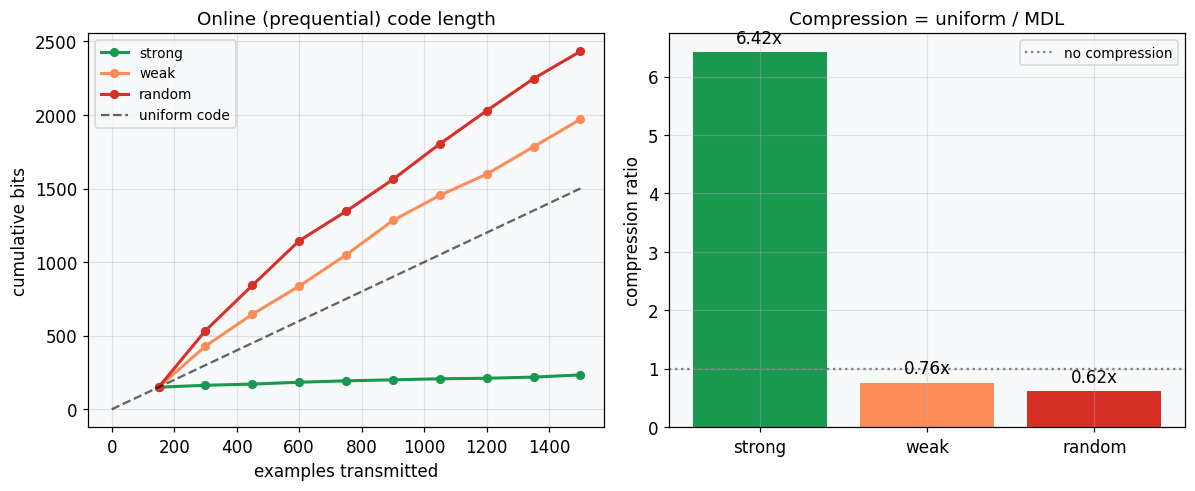

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
colors = {'strong': '#1a9850', 'weak': '#fc8d59', 'random': '#d73027'}
ax = axes[0]
for name, (seen, curve) in curves.items():
    ax.plot(seen, curve, 'o-', color=colors[name], lw=2, ms=5, label=name)
ax.plot([0, N], [0, uniform_bits], 'k--', alpha=0.6, label='uniform code')
ax.set_title('Online (prequential) code length')
ax.set_xlabel('examples transmitted'); ax.set_ylabel('cumulative bits')
ax.legend(fontsize=9)
ax = axes[1]
names = list(reps)
comp = [uniform_bits / totals[n] for n in names]
ax.bar(names, comp, color=[colors[n] for n in names])
for i, c in enumerate(comp):
    ax.annotate(f'{c:.2f}x', (i, c), textcoords='offset points', xytext=(0, 6), ha='center')
ax.axhline(1.0, color='gray', ls=':', label='no compression')
ax.set_title('Compression = uniform / MDL')
ax.set_ylabel('compression ratio'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

Left: the **strong** representation's code length flattens quickly — once the probe has seen a little
data it predicts the rest almost for free, so few bits accrue. The **weak** curve bends less, and the
**random** curve tracks the uniform-code diagonal (1 bit/example): it never compresses because the
labels are independent of $Z$. Right: compression ratio (uniform ÷ MDL) ranks them cleanly.

MDL folds *both* the probe's quality and the **effort** to reach it into a single number of bits — so
it separates a genuinely informative representation from one a strong probe merely brute-forces, and
it does so without hand-tuning a control task. This is the information-theoretic school's answer to
the capacity dilemma of Experiment 3.

## Experiment 5 (limitation): no single steering direction

**Question:** A linear probe hands us a weight vector $W$ to *move* a latent. Does a nonlinear probe
give anything comparable?

It does not. We take a fixed candidate steering direction (the class-mean difference) and walk along
it. For a **linearly** encoded attribute the probe's $P(\text{class }1)$ rises smoothly; for the
**XOR** attribute the same straight walk crosses in and out of the class repeatedly — there is no
global direction that turns the concept up.

In [10]:
np.random.seed(5)
m = 900
# linear-encoded latent
Zl = np.random.randn(m, 2)
yl = (Zl[:, 0] + 0.4 * Zl[:, 1] > 0).astype(int)
# XOR-encoded latent
Zx = np.random.randn(m, 2) * 1.1
yx = ((Zx[:, 0] > 0) ^ (Zx[:, 1] > 0)).astype(int)

mlp_l = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=5).fit(Zl, yl)
mlp_x = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=5).fit(Zx, yx)

def walk(Z, y, model):
    d = Z[y == 1].mean(0) - Z[y == 0].mean(0)   # class-mean difference direction
    d = d / (np.linalg.norm(d) + 1e-9)
    start = Z[y == 0].mean(0)
    steps = np.linspace(0, 6, 40)
    probs = model.predict_proba(start + steps[:, None] * d)[:, 1]
    return steps, probs

steps_l, probs_l = walk(Zl, yl, mlp_l)
steps_x, probs_x = walk(Zx, yx, mlp_x)
print('linear  : monotonic?', bool(np.all(np.diff(probs_l) >= -1e-3)))
print('XOR     : monotonic?', bool(np.all(np.diff(probs_x) >= -1e-3)))

linear  : monotonic? True
XOR     : monotonic? False


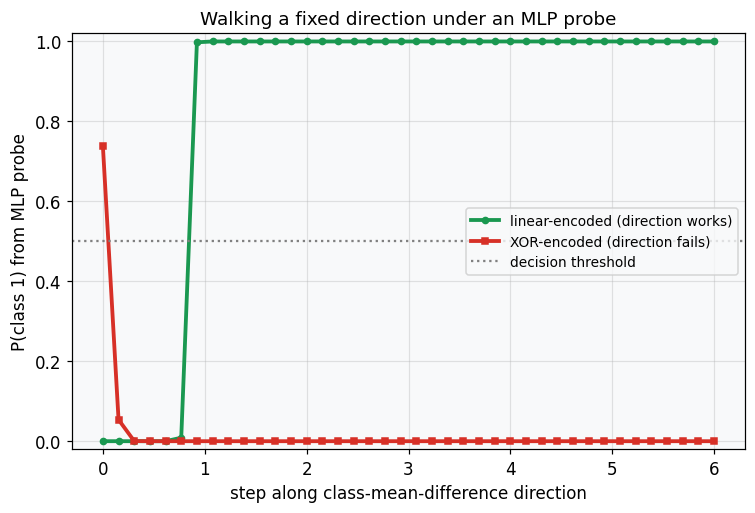

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(steps_l, probs_l, 'o-', color='#1a9850', lw=2.5, ms=4,
        label='linear-encoded (direction works)')
ax.plot(steps_x, probs_x, 's-', color='#d73027', lw=2.5, ms=4,
        label='XOR-encoded (direction fails)')
ax.axhline(0.5, color='gray', ls=':', label='decision threshold')
ax.set_title('Walking a fixed direction under an MLP probe')
ax.set_xlabel('step along class-mean-difference direction')
ax.set_ylabel('P(class 1) from MLP probe')
ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

For the linearly-encoded attribute (green) the class-mean-difference direction *is* a valid steering
axis: $P(\text{class }1)$ climbs monotonically from ~0 to ~1. For the XOR attribute (red) the same
straight walk oscillates — it dips back below the threshold because the two class-1 quadrants sit on
opposite sides of the start point. **No fixed linear direction steers an XOR concept.**

This is the practical limitation that keeps nonlinear probing on the introspection side of the house:
it can *detect* a feature (Experiments 1–2) but it does not produce a usable concept direction for
Layer B. Its job is to be a **gatekeeper** — confirm the information exists — before the linear probe
(or a dedicated steering-vector method) goes looking for a direction to act on.

## Summary / Key Takeaways

- **Exp 1** — An MLP probe bends the boundary and recovers nonlinearly-encoded attributes; its
  accuracy upper-bounds the linear probe ($\mathrm{Acc}_{\text{MLP}}\ge\mathrm{Acc}_{\text{linear}}$).
- **Exp 2** — The (linear, MLP) accuracy pair is a diagnostic: both-high = linear encoding, low-then-high
  = nonlinear encoding, both-low = no information.
- **Exp 3** — Capacity always lifts accuracy but also control-task accuracy, so **selectivity falls** —
  never report bare nonlinear-probe accuracy.
- **Exp 4** — **MDL / online coding** grades representations in bits, folding quality *and* effort into
  one number, and cleanly separates informative from brute-forced.
- **Exp 5** — A nonlinear probe yields **no single steering direction**, so it stays an introspection
  gatekeeper, not a manipulation tool.
